# Стохастический градиентный и координатный спуски

Для каждого задания указано количество баллов (если они оцениваются отдельно) + 1 балл за аккуратное и полное выполнение всего задания

## Загрузка и подготовка данных

**Загрузите уже знакомый вам файл *Advertising.csv* как объект DataFrame.** 

In [130]:
# Импорт библиотек
import numpy as np # для работы с массивами
import pandas as pd # для работы с DataFrame 
import seaborn as sns # библиотека для визуализации статистических данных
import matplotlib.pyplot as plt # для построения графиков

In [131]:
df = pd.read_csv('Advertising.csv')
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


**Проверьте, есть ли в данных пропуски и, если они есть - удалите их**

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [133]:
df.isna().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

**Преобразуйте ваши признаки в массивы NumPy и разделите их на переменные X (предикторы) и y(целевая переменная)** 

In [134]:
feature_columns = ['TV', 'radio', 'newspaper']
target_column = 'sales'

In [135]:
X = df[feature_columns].to_numpy()
y = df[target_column].to_numpy().reshape(-1, 1)  # Преобразуем в столбец (n, 1)

# Проверка результатов
print("Форма X:", X.shape)
print("Форма y:", y.shape)
print("\nТип X:", type(X))
print("Тип y:", type(y))
print("\nПервые 5 строк X:\n", X[:5])
print("\nПервые 5 значений y:\n", y[:5])

Форма X: (200, 3)
Форма y: (200, 1)

Тип X: <class 'numpy.ndarray'>
Тип y: <class 'numpy.ndarray'>

Первые 5 строк X:
 [[230.1  37.8  69.2]
 [ 44.5  39.3  45.1]
 [ 17.2  45.9  69.3]
 [151.5  41.3  58.5]
 [180.8  10.8  58.4]]

Первые 5 значений y:
 [[22.1]
 [10.4]
 [ 9.3]
 [18.5]
 [12.9]]


## Координатный спуск (3 балла)

**Добавим единичный столбец для того, чтобы у нас был свободный коэффициент в уравнении регрессии:**

In [136]:
X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])
print(X.shape, y.shape)

(200, 4) (200, 1)


**Нормализуем данные: обычно это необходимо для корректной работы алгоритма**

In [137]:
X = X / np.sqrt(np.sum(np.square(X), axis=0))

**Реализуйте алгоритм координатного спуска:** (3 балла)

Ниже приведен алгоритм координатного спуска для случая нормализованных данных:

**Задано:**

* $X=(x_{ij})$ - матрица наблюдений, размерностью $dim(X)=(m, n)$
* $N=1000$ - количество итераций

**Примечание:** *1000 итераций здесь указаны для этого задания, на самом деле их может быть намного больше, нет детерменированного значения.*

**Алгоритм (математическая запись):**
* Создать нулевой вектор параметров $w_0=(0, 0,..., 0)^T$
* Для всех $t=1, 2, ..., N$ итераций:
    * Для всех $k = 1, 2,..., n$:
        * Фиксируем значение всех признаков, кроме $k$-ого и вычисляем прогноз модели линейной регрессии.Для этого исключаем признак $k$-ый из данных и $w_j$ из параметров при построении прогноза.
        Математически это можно записать следующим образом:

        $$h_i = \sum_{j=1}^{k-1} x_{ij}w_{j} + \sum_{j=k+1}^{n} x_{ij}w_j $$

        **Примечание:**
        
        *Обратите, что в данной записи текущий признак под номером $k$ не участвует в сумме.Сравните эту запись с классической записью прогноза линейной регрессии в случае нормированных данных (когда участвуют все признаки):*

        $$h_i = \sum_{j=1}^{n} x_{ij}w_{j}$$ 
        
        * Вычисляем новое значение параметра $k$-ого коэффициента: 
        $$w_k = \sum_{i=1}^{m} x_{ik} (y_i - h_i) = x_k^T(y-h) $$

    * Вычисляем значение функции потерь и сохраняем в историю изменения функции потерь (В оценке функции потерь участвуют все признаки):
        $$\hat{y_i} = \sum_{j=1}^{n}x_{ij}w_j$$
        $$Loss_t = \frac{1}{n} \sum_{i=1}^{m}(y_i-\hat{y_i})^2$$
        
        или в векторном виде:
        
        $$\hat{y} = Xw$$
        $$Loss_t = \frac{1}{n}(y-\hat{y})^T(y-\hat{y})$$
    



**Алгоритм (псевдокод):**
```python

num_iters = #количество итераций
m = # количество строк в матрице X
n = # количество столбцов в матрице X
w = #вектор размера nx1, состояющий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum((X @ w) - y) ** 2)/(len(y))

```

Вам необходимо реализовать координатный спуск, и вывести веса в модели линейной регрессии.

In [138]:
# Задаём количество столбцов и строк в матрице X
m = X.shape[1]
n = X.shape[0]

# Задаём вектор, состоящий из нулей
w = np.zeros((m, 1))

# Задаем количество итераций
num_iters = 1000

# Создаём пустые массивы для фиксации MSE и MAE
mse_values = np.array([])
mae_values = np.array([])

for _ in range(num_iters):
    for k in range(m):
    # вычисляем прогноз без k-ого фактора
        h = (X[:, 0:k] @ w[0:k]) + (X[:, k + 1:] @ w[k + 1:])
            
        # вычисляем новое значение k-ого коэффициента
        w[k] = (X[:, k].T @ (y - h))

    # Вычисляем метрики после полного прохода по всем признакам
        y_pred = X @ w
        mse = np.mean((y - y_pred) ** 2)
        mae = np.mean(np.abs(y - y_pred))

    # Добавляем значения
        mse_values = np.append(mse_values, mse)
        mae_values = np.append(mae_values, mae)

# Выводим результаты
TOL = 4
print(f'Коэффициенты линейной регрессии:\n{w.flatten()}')
print(f'Метрика MSE: {mse_values[-1]:.{TOL}f}')
print(f'Метрика MAE: {mae_values[-1]:.{TOL}f}')

Коэффициенты линейной регрессии:
[ 41.56217205 110.13144155  73.52860638  -0.55006384]
Метрика MSE: 2.7841
Метрика MAE: 1.2520


Сравните результаты с реализацией линейной регрессии из библиотеки sklearn:

In [139]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_LR = LinearRegression(fit_intercept=False)
model_LR.fit(X, y)
 
print(model_LR.coef_)

# Расчет метрик
y_pred_LR = model_LR.predict(X)
mae = mean_absolute_error(y, y_pred_LR)
mse = mean_squared_error(y, y_pred_LR)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

[[ 41.56217205 110.13144155  73.52860638  -0.55006384]]
MSE: 2.7841
MAE: 1.2520


Если вы все сделали верно, они должны практически совпасть!

## Стохастический градиентный спуск (6 баллов)

**Отмасштабируйте столбцы исходной матрицы *X* (которую мы не нормализовали еще!). Для того, чтобы это сделать, надо вычесть из каждого значения среднее и разделить на стандартное отклонение** (0.5 баллов)

In [140]:
# Разделение на признаки и целевую переменную
X = df[['TV', 'radio', 'newspaper']].values
y = df['sales'].values.reshape(-1, 1)

# Стандартизация признаков
X = (X - X.mean(axis=0)) / X.std(axis=0)

**Добавим единичный столбец**

In [141]:
X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])

# выводим результаты
print(X.shape, y.shape)
print(X[:5])
print(y[:5])

(200, 4) (200, 1)
[[ 1.          0.96985227  0.98152247  1.77894547]
 [ 1.         -1.19737623  1.08280781  0.66957876]
 [ 1.         -1.51615499  1.52846331  1.78354865]
 [ 1.          0.05204968  1.21785493  1.28640506]
 [ 1.          0.3941822  -0.84161366  1.28180188]]
[[22.1]
 [10.4]
 [ 9.3]
 [18.5]
 [12.9]]


**Создайте функцию mse_error для вычисления среднеквадратичной ошибки, принимающую два аргумента: реальные значения и предсказывающие, и возвращающую значение mse** (0.5 балла)

In [142]:
def mse_error(y_true, y_pred):
    """Вычисляет среднеквадратичную ошибку (MSE)
    Args:
        y_true (np.ndarray): вектор целевых значений (таргет)
        
        y_pred (np.ndarray): вектор предсказанных целевых значений

    Returns:
        (float): значение среднеквадратичной ошибки
    """
    return np.mean((y_true - y_pred) ** 2)

**Сделайте наивный прогноз: предскажите продажи средним значением. После этого рассчитайте среднеквадратичную ошибку для этого прогноза** (0.5 балла)

In [143]:
# наивный прогноз продаж средним значением
y_pred_naive = np.full(y.shape, y.mean())

# выводим результаты
print(f'Метрика MSE для наивного прогноза: {mse_error(y, y_pred_naive):.{TOL}f}')

Метрика MSE для наивного прогноза: 27.0857


In [144]:
# проверяем полученный результат для среднеквадратичной ошибки с помощью sklearn
print(f'Метрика MSE для наивного прогноза (sklearn): {mean_squared_error(y, y_pred_naive):.{TOL}f}')

Метрика MSE для наивного прогноза (sklearn): 27.0857


**Создайте функцию *lin_pred*, которая может по матрице предикторов *X* и вектору весов линейной модели *w* получить вектор прогнозов** (0.5 балла)

In [145]:
def lin_pred(X_, w_):
    """ Функция, реализующая вектор прогнозов

    Args:
        X_ (np.ndarray): матрица наблюдений (предикторы)

        w_ (np.ndarray): вектор весов линейной модели

    Returns:
        (np.ndarray): вектор прогнозов
    """

    # преобразуем вектор в одномерный массив
    w_ = w_.reshape(-1, 1)
    
    # получаем вектор прогнозов линейной модели, 
    # преобразуем в одномерный массив
    return (X_ @ w_).reshape(-1, 1)

**Создайте функцию *stoch_grad_step* для реализации шага стохастического градиентного спуска. (1.5 балла) 
Функция должна принимать на вход следующие аргументы:**
* матрицу *X*
* вектора *y* и *w*
* число *train_ind* - индекс объекта обучающей выборки (строки матрицы *X*), по которому считается изменение весов
* число *$\eta$* (eta) - шаг градиентного спуска

Результатом будет вектор обновленных весов

Шаг для стохастического градиентного спуска выглядит следующим образом:

$$\Large w_j \leftarrow w_j - \frac{2\eta}{\ell} \sum_{i=1}^\ell{{x_{ij}((w_0 + w_1x_{i1} + w_2x_{i2} +  w_3x_{i3}) - y_i)}}$$

Для того, чтобы написать функцию, нужно сделать следующее:
    
*  посчитать направление изменения: умножить объект обучающей выборки на 2 и на разницу между предсказанным значением и реальным, а потом поделить на количество элементов в выборке.
* вернуть разницу между вектором весов и направлением изменения, умноженным на шаг градиентного спуска

In [146]:
def stoch_grad_step(X_, y_, w_, train_ind, eta):
    """ Функция, реализующая шаг стохастического градиентного спуска

    Args:
        X_ (np.ndarray): матрица наблюдений (предикторы)

        y_ (np.ndarray): вектор целевых значений (таргет)
        
        w_ (np.ndarray): вектор весов линейной модели
        
        train_ind (int):    индекс объекта обучающей выборки (строки матрицы X), 
                            по которому считается изменение весов

        eta (float): шаг градиентного спуска

    Returns:
        (np.ndarray): обновленный вектор весов линейной модели
    """

    # вычисляем разницу между предсказанным и реальным значением
    diff = lin_pred(X_[train_ind], w_) - y_[train_ind]

    # вычисляем направление изменения весов модели
    direction = X_[train_ind, :] * 2 * diff / len(y_)
    
    # обновляем веса (коэффициенты) модели
    return  w_ - direction * eta

**Создайте функцию *stochastic_gradient_descent*, для реализации стохастического градиентного спуска (2.5 балла)**

**Функция принимает на вход следующие аргументы:**
- Матрицу признаков X
- Целевую переменнную
- Изначальную точку (веса модели)
- Параметр, определяющий темп обучения
- Максимальное число итераций
- Евклидово расстояние между векторами весов на соседних итерациях градиентного спуска,при котором алгоритм прекращает работу 

**На каждой итерации в вектор (список) должно записываться текущее значение среднеквадратичной ошибки. Функция должна возвращать вектор весов $w$, а также вектор (список) ошибок.**

Алгоритм сследующий:
    
* Инициализируйте расстояние между векторами весов на соседних итерациях большим числом (можно бесконечностью)
* Создайте пустой список для фиксации ошибок
* Создайте счетчик итераций
* Реализуйте оновной цикл обучения пока расстояние между векторами весов больше того, при котором надо прекратить работу (когда расстояния станут слишком маленькими - значит, мы застряли в одном месте) и количество итераций меньше максимально разрешенного: сгенерируйте случайный индекс, запишите текущую ошибку в вектор ошибок, запишите в переменную текущий шаг стохастического спуска с использованием функции, написанной ранее. Далее рассчитайте текущее расстояние между векторами весов и прибавьте к счетчику итераций 1.
* Верните вектор весов и вектор ошибок

In [147]:
def stochastic_gradient_descent(
        X_:np.ndarray=X, 
        y_:np.ndarray=y, 
        w_init:np.ndarray=w, 
        eta:float=0.01, 
        max_iter:int=1e5, 
        min_weight_dist:float=1e-8
    ) -> np.ndarray | list[float]:
    """ Функция, реализующая вычисление вектора коэффициентов методом стохастического градиентного спуска.

    Args:
        X_ (np.ndarray, optional): матрица наблюдений (предикторы). Defaults to X.
        
        y_ (np.ndarray, optional): вектор целевых значений (таргет). Defaults to y.
        
        w_init (np.ndarray, optional): пустой вектор коэффициентов. Defaults to w.
        
        eta (float, optional): темп обучения. Defaults to 0.01.
        
        max_iter (int, optional): максимальное число итераций. Defaults to 1e5.
        
        min_weight_dist (float, optional):  минимальное расстояние между векторами весов на соседних итерациях 
                                            градиентного спуска, при котором алгоритм прекращает работу. 
                                            Defaults to 1e-8.

    Returns:
        w (np.ndarray): веса (коэффициенты) линейной модели
        
        mse_ (np.ndarray): массив значений среднеквадратичных ошибок
    """
    
    # задаём расстояние между векторами весов
    weight_dist = np.inf

    # создаём пустой массив для фиксации MSE
    mse_ = np.array([])

    # создаём счетчик итераций
    iter_num = 0

    # задаём начальный вектор весов
    w = w_init

    # выполняем цикл пока расстояние между векторами весов больше того,
    # при котором будет прекращена работа и количество итераций меньше максимума
    while weight_dist > min_weight_dist and iter_num < max_iter:
        # задаём случайный индекс
        random_index = np.random.randint(len(y))

        # записываем в переменную текущий шаг стохастического спуска
        w_new = stoch_grad_step(X_, y_, w, random_index, eta)

        # вычисляем текущее расстояние между векторами весов
        weight_dist = np.linalg.norm(w - w_new)

        # вычисляем MSE
        mse_ = np.append(mse_, mse_error(y, lin_pred(X, w)))

        # обновляем вектор весов и индекс итерации
        w = w_new
        iter_num += 1

    return w, mse_

 **Запустите $10^5$ итераций стохастического градиентного спуска. Укажите вектор начальных весов, состоящий из нулей. Можете поэкспериментировать с параметром, отвечающим за темп обучения.**

In [148]:
# задаём нулевой вектор коэффициентов (весов модели)
w = np.zeros(4)

# выполняем алгоритм стохастического градиентного спуска, получаем результаты
w_stoch_grad_desc, mse_stoch_grad_desc = stochastic_gradient_descent(X, y, w)

# выводим результаты
print(f'Количество итераций: {len(mse_stoch_grad_desc)}')
mse_stoch_grad_desc

Количество итераций: 67728


array([223.71625   , 223.69512335, 223.62768199, ...,   2.78468451,
         2.78467711,   2.78467492])

**Постройте график зависимости ошибки от номера итерации**

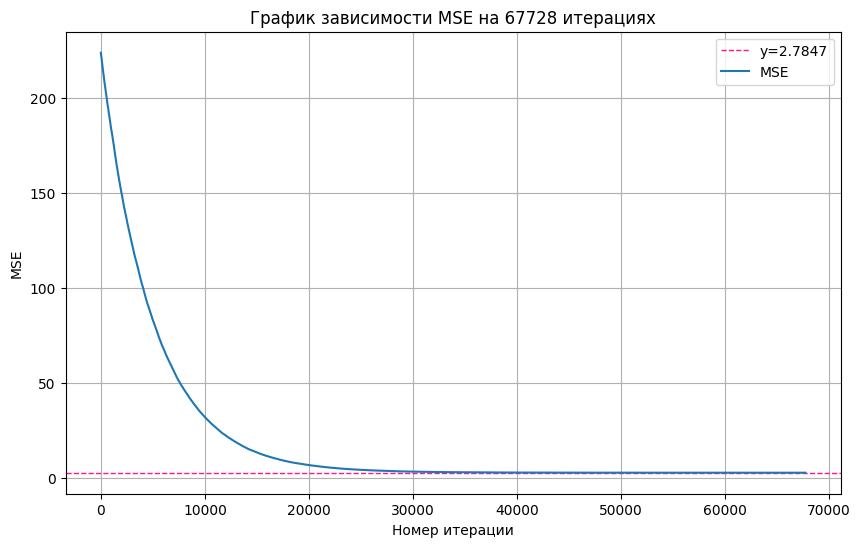

In [149]:
# задаём размер полотна
fig = plt.figure(figsize=(10, 6))
plt.grid()

# рисуем график уровня последнего значения MSE
plt.axhline(mse_stoch_grad_desc[-1], lw=1, c='deeppink', linestyle='--', label=f'y={mse_stoch_grad_desc[-1]:.{TOL}f}')

# рисуем график MSE
plt.plot(mse_stoch_grad_desc, label='MSE')

# задаём отображение легенды
plt.legend()

# задаём заголовок и подписи осей
plt.title(f'График зависимости MSE на {len(mse_stoch_grad_desc)} итерациях')
plt.ylabel('MSE')
plt.xlabel('Номер итерации');

**Выведите вектор весов, к которому сошелся метод.**

In [150]:
w_stoch_grad_desc

array([[14.01247891,  3.93365847,  2.77837835, -0.02806256]])

**Выведите среднеквадратичную ошибку на последней итерации.**

In [151]:
print(f'MSE на последней итерации: {mse_stoch_grad_desc[-1]:.{TOL}f}')

MSE на последней итерации: 2.7847


In [152]:
# выводим результаты метрики MSE и MAE на всех данных
print(f'Метрика MSE (sklearn): {mean_squared_error(y, lin_pred(X, w_stoch_grad_desc)):.{TOL}f}')
print(f'Метрика MAE (sklearn): {mean_absolute_error(y, lin_pred(X, w_stoch_grad_desc)):.{TOL}f}')

Метрика MSE (sklearn): 2.7847
Метрика MAE (sklearn): 1.2550


**Выводы:**

- Решение, полученное при ручной реализации координатного спуска для линейной регрессии, совпадает с реализацией линейной регрессии с библиотекой sklearn;

- Наивный прогноз даёт результат в 10 раз хуже (27.0857 против 2.7847);

- Стохастический градиентный спуск быстрее минимизирует ошибку, за меньшее количество итераций, чем 1e5;

- Метрики MSE и MAE - совпадают до 2-го знака после запятой, включительно, а коэффициенты вектора весов - отличны друг от друга;

- Оба алгоритма (ручные - координатный и стохастический градиентный и из библиотеки sklearn) сошлись на одном уровне - об этом говорят одинаковые метрики MSE, но в разных точках пространства - об этом говорят разные вектора весов.